# Simulated root

Perform a water flow simulation on a simulated root architecture.

In [1]:
import pandas 
from openalea.hydroroot.main import root_builder, hydroroot_flow
from openalea.widgets.plantgl import PlantGL # notebook viewer 3D
from openalea.plantgl.algo.view import view # 2D view
from openalea.hydroroot.display import mtg_scene

## Architecture generation

The Hydroroot generator of architecture is described in ([Boursiac et al., 2022](https://doi.org/10.1093/plphys/kiac281)). It uses length distribution law for laterals, specific to a given species, to generate realistic architecture. Here we use the length laws determinated for Arabidopsis Col0.

In [2]:
length_data = [] # length law used to generate arabidopsis realistic architecture
for filename in ['data/length_LR_order1_160615.csv','data/length_LR_order2_160909.csv']:
    df = pandas.read_csv(filename, sep = ';', header = 1, names = ('LR_length_mm', 'relative_distance_to_tip'))
    df.sort_values(by = 'relative_distance_to_tip', inplace = True)
    length_data.append(df)

We generate the MTG with some specific parameters:
+ primary_length: length of the primary root
+ delta: the average distance between lateral branching
+ branching_variability: the variability of the branching distance around delta
+ nude_length: distance from the tip without any laterals
+ order_max: the maximum order of laterals

And return the primary root length, the total length and the surface.  Seed may be used as seed to generate the same architecture.

In [3]:
g, primary_length, total_length, surface, seed = root_builder(primary_length = 0.13, delta = 2.0e-3, nude_length = 2.0e-2, segment_length = 1.0e-4,
                                                  length_data = length_data, branching_variability = 0.25, order_max = 4.0, order_decrease_factor = 0.7,
                                                  ref_radius = 7.0e-5)

## Run calculation

Some conductance data versus distance to tip

In [4]:
k_radial_data=([0, 0.2],[30.0,30.0])
K_axial_data=([0, 0.2],[3.0e-7,4.0e-4])

Flux and equivalent conductance calculation, for a root in an external hydroponic medium at 0.4 MPa, its base at 0.1 MPa, and with the conductances set above.

In [5]:
g, keq, jv = hydroroot_flow(g, psi_e = 0.4, psi_base = 0.1, axial_conductivity_data = K_axial_data, radial_conductivity_data = k_radial_data)

In [6]:
print(keq,jv)

0.006965392821935138 0.0020896178465805416


## Display the local water uptake heatmap

to reduce notebook size we use here a 2D view but you can use the openalea.widgets `PlantGL(s)` to display an interactive 3D view

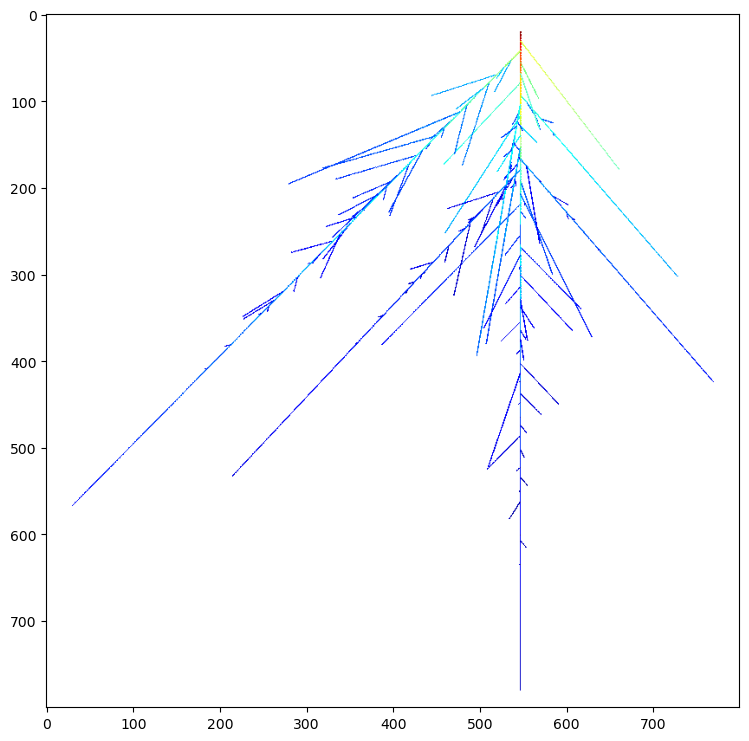

In [7]:
s = mtg_scene(g, prop_cmap = 'j') # create a scene from the mtg with the property j is the radial flux in ul/s
view(s) # use PlantGL(s) to display in 3D